In [2]:
import numpy as np
import plotly.graph_objects as go

# --- Grid setup ---
Lx, Ly = 3000, 2000
nx, ny = 200, 150
x = np.linspace(-Lx/2, Lx/2, nx)
y = np.linspace(-Ly/2, Ly/2, ny)
X, Y = np.meshgrid(x, y)

# --- Twin Gaussian parameters ---
h1, h2 = 600, 300  # depths
x1, x2 = -800, 800
y1 = y2 = 0
sigma = 400

def twin_gaussian_basins(X, Y, x1, y1, h1, x2, y2, h2, sigma):
    basin1 = h1 * np.exp(-((X - x1)**2 + (Y - y1)**2) / (2 * sigma**2))
    basin2 = h2 * np.exp(-((X - x2)**2 + (Y - y2)**2) / (2 * sigma**2))
    return -(basin1 + basin2)

Z = twin_gaussian_basins(X, Y, x1, y1, h1, x2, y2, h2, sigma)

# --- Create interactive surface plot ---
fig = go.Figure(data=[go.Surface(z=Z, x=X, y=Y, colorscale='RdBu', colorbar=dict(title='Depth (m)'))])

fig.update_layout(
    title='Interactive 3D View of Twin Gaussian Basins',
    scene=dict(
        xaxis_title='x (m)',
        yaxis_title='y (m)',
        zaxis_title='Depth (m)',
        aspectratio=dict(x=2, y=1.5, z=0.5),
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
    ),
    margin=dict(l=0, r=0, b=0, t=30)
)



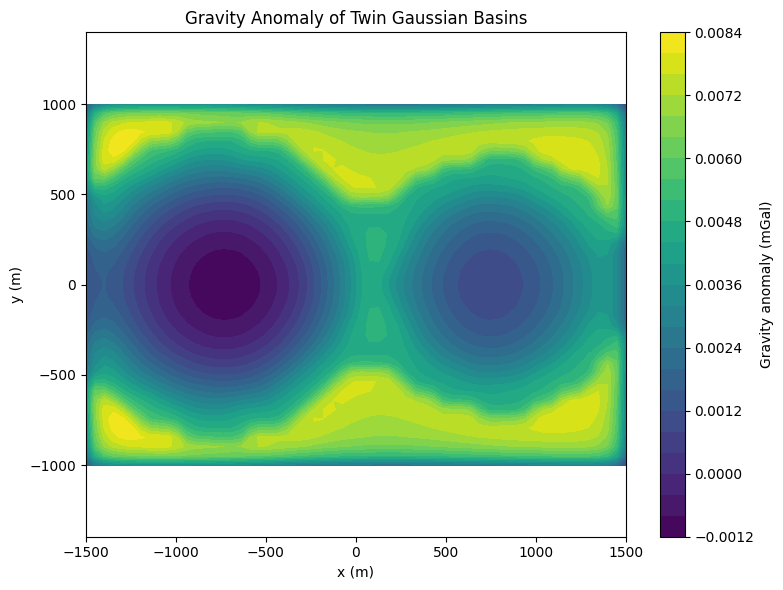

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
from gravity3d import compute_gravity

# --- Constants ---
G = 6.67430e-11         # m^3/kg/s^2
G_mGal = G * 1e5        # conversion to mGal
density_contrast = 300  # kg/m^3 (sediment is less dense)

# --- Grid setup ---
Lx, Ly = 3000, 2000
nx, ny, nz = 40, 30, 10
x_edges = np.linspace(-Lx/2, Lx/2, nx+1)
y_edges = np.linspace(-Ly/2, Ly/2, ny+1)
z_edges = np.linspace(-600, 0, nz+1)
xc = 0.5 * (x_edges[:-1] + x_edges[1:])
yc = 0.5 * (y_edges[:-1] + y_edges[1:])
zc = 0.5 * (z_edges[:-1] + z_edges[1:])
Xc, Yc, Zc = np.meshgrid(xc, yc, zc, indexing='ij')

# --- Twin Gaussian basin surface ---
h1, h2 = 600, 300
x1, x2 = -800, 800
sigma = 400
basin_surface = -(h1 * np.exp(-((Xc[:, :, 0] - x1)**2 + Yc[:, :, 0]**2) / (2 * sigma**2)) +
                  h2 * np.exp(-((Xc[:, :, 0] - x2)**2 + Yc[:, :, 0]**2) / (2 * sigma**2)))

# --- Density model ---
rho_model = np.zeros((nx, ny, nz))
for iz in range(nz):
    z_top = z_edges[iz + 1]
    rho_model[:, :, iz] = density_contrast * (z_top < basin_surface)

# --- Observation points ---
x_obs = np.linspace(-Lx/2, Lx/2, 60)
y_obs = np.linspace(-Ly/2, Ly/2, 40)
Xobs, Yobs = np.meshgrid(x_obs, y_obs, indexing='ij')
Zobs = np.zeros_like(Xobs)

# --- Run forward model ---
gz_obs = compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_model)

# --- Plot gravity anomaly ---
plt.figure(figsize=(8, 6))
cp = plt.contourf(Xobs, Yobs, gz_obs, levels=30)
plt.colorbar(cp, label='Gravity anomaly (mGal)')
plt.title('Gravity Anomaly of Twin Gaussian Basins')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.axis('equal')
plt.tight_layout()
plt.show()


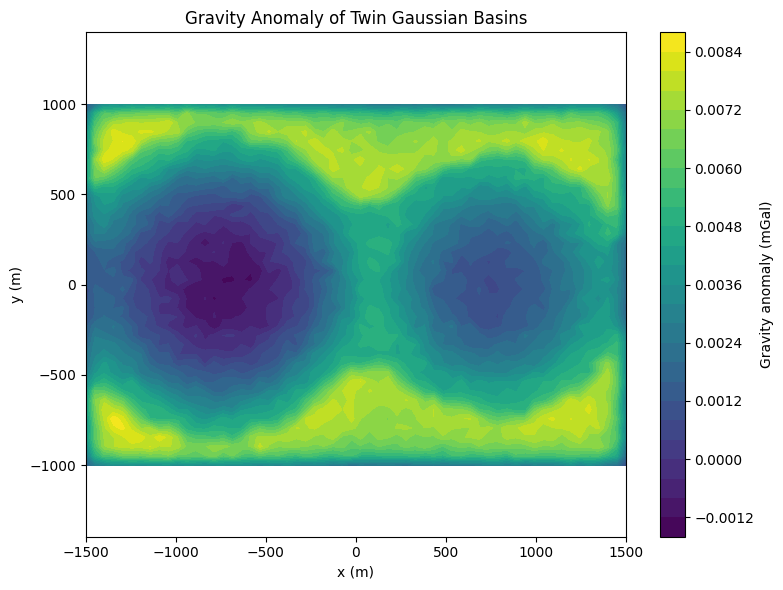

In [2]:
noise_std = 0.0002  # mGal standard deviation
np.random.seed(42)  # For reproducibility
gz_obs_noisy = gz_obs + np.random.normal(0, noise_std, gz_obs.shape)
# --- Plot gravity anomaly ---
plt.figure(figsize=(8, 6))
cp = plt.contourf(Xobs, Yobs, gz_obs_noisy, levels=30)
plt.colorbar(cp, label='Gravity anomaly (mGal)')
plt.title('Gravity Anomaly of Twin Gaussian Basins')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.axis('equal')
plt.tight_layout()
plt.show()


In [4]:
import pandas as pd

data = {
    'x': Xobs.ravel(),
    'y': Yobs.ravel(),
    'gz_obs': gz_obs_noisy.ravel()  # or gz_obs.ravel() if no noise added
}

df = pd.DataFrame(data)
df.to_csv('obs_gravity_anomaly.csv', index=False)


AttributeError: partially initialized module 'pandas' has no attribute '_pandas_parser_CAPI' (most likely due to a circular import)

differential_evolution step 1: f(x)= 0.0014826884514556765
differential_evolution step 2: f(x)= 0.000964951768798404
differential_evolution step 3: f(x)= 0.000964951768798404
differential_evolution step 4: f(x)= 0.0004632031378825229
differential_evolution step 5: f(x)= 0.0004632031378825229
Polishing solution with 'L-BFGS-B'

Recovered Parameters:
h1 = 743.43, h2 = 606.30
x1 = -769.40, x2 = 736.44
sigma = 349.53


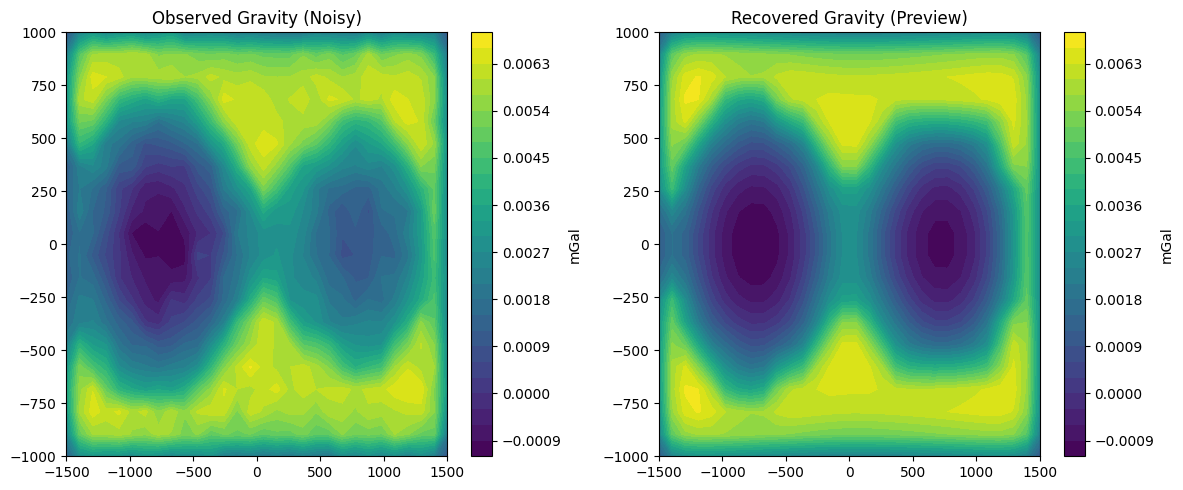

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
from scipy.optimize import differential_evolution

# Constants
G = 6.67430e-11
G_mGal = G * 1e5
density_contrast = 300  # fixed

# Grid (Reduced)
Lx, Ly = 3000, 2000
nx, ny, nz = 20, 15, 6
x_edges = np.linspace(-Lx/2, Lx/2, nx+1)
y_edges = np.linspace(-Ly/2, Ly/2, ny+1)
z_edges = np.linspace(-600, 0, nz+1)
xc = 0.5 * (x_edges[:-1] + x_edges[1:])
yc = 0.5 * (y_edges[:-1] + y_edges[1:])
zc = 0.5 * (z_edges[:-1] + z_edges[1:])
Xc, Yc, Zc = np.meshgrid(xc, yc, zc, indexing='ij')

# Observation Points (Reduced)
x_obs = np.linspace(-Lx/2, Lx/2, 30)
y_obs = np.linspace(-Ly/2, Ly/2, 20)
Xobs, Yobs = np.meshgrid(x_obs, y_obs, indexing='ij')
Zobs = np.zeros_like(Xobs)

# Prism Gravity Kernel
@njit
def prism_gz(xo, yo, zo, x1, x2, y1, y2, z1, z2, drho):
    gz = 0.0
    for i in [x1, x2]:
        for j in [y1, y2]:
            for k in [z1, z2]:
                dx = i - xo
                dy = j - yo
                dz = k - zo
                R = np.sqrt(dx**2 + dy**2 + dz**2 + 1e-10)
                sign = (-1)**((i == x2) + (j == y2) + (k == z2))
                gz += sign * np.arctan2(dx * dy, dz * R + 1e-10)
    return G_mGal * drho * gz

@njit(parallel=True)
def compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_model):
    nx, ny, nz = rho_model.shape
    nobs_x, nobs_y = Xobs.shape
    gz_obs = np.zeros((nobs_x, nobs_y))

    for i in prange(nobs_x):
        for j in range(nobs_y):
            xo, yo, zo = Xobs[i, j], Yobs[i, j], Zobs[i, j]
            gz = 0.0
            for ix in range(nx):
                for iy in range(ny):
                    for iz in range(nz):
                        drho = rho_model[ix, iy, iz]
                        if drho == 0:
                            continue
                        x1, x2 = x_edges[ix], x_edges[ix + 1]
                        y1, y2 = y_edges[iy], y_edges[iy + 1]
                        z1, z2 = z_edges[iz], z_edges[iz + 1]
                        gz += prism_gz(xo, yo, zo, x1, x2, y1, y2, z1, z2, drho)
            gz_obs[i, j] = gz
    return gz_obs

# True Parameters
h1_true, h2_true = 600, 300
x1_true, x2_true = -800, 800
sigma_true = 400

# True Basin Surface
basin_surface_true = -(h1_true * np.exp(-((Xc[:, :, 0] - x1_true)**2 + Yc[:, :, 0]**2) / (2 * sigma_true**2)) +
                       h2_true * np.exp(-((Xc[:, :, 0] - x2_true)**2 + Yc[:, :, 0]**2) / (2 * sigma_true**2)))

# True Density Model
rho_true = np.zeros((nx, ny, nz))
for iz in range(nz):
    z_top = z_edges[iz + 1]
    rho_true[:, :, iz] = density_contrast * (z_top < basin_surface_true)

gz_true = compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_true)
np.random.seed(42)
gz_obs_noisy = gz_true + np.random.normal(0, 0.0002, gz_true.shape)

# Forward Model
def forward_model(params):
    h1, h2, x1, x2, sigma = params
    sigma = max(sigma, 1.0)
    basin_surface = -(h1 * np.exp(-((Xc[:, :, 0] - x1)**2 + Yc[:, :, 0]**2) / (2 * sigma**2)) +
                      h2 * np.exp(-((Xc[:, :, 0] - x2)**2 + Yc[:, :, 0]**2) / (2 * sigma**2)))
    rho_model = np.zeros((nx, ny, nz))
    for iz in range(nz):
        z_top = z_edges[iz + 1]
        rho_model[:, :, iz] = density_contrast * (z_top < basin_surface)
    return compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_model)

# Misfit
def misfit(params):
    return np.sum((forward_model(params) - gz_obs_noisy)**2)

# Differential Evolution (Reduced)
bounds = [
    (100, 1000),  # h1
    (100, 1000),  # h2
    (-1500, 0),   # x1
    (0, 1500),    # x2
    (100, 1000),  # sigma
]

result = differential_evolution(misfit, bounds, strategy='best1bin', popsize=6, maxiter=5, disp=True)

print("\nRecovered Parameters:")
print(f"h1 = {result.x[0]:.2f}, h2 = {result.x[1]:.2f}")
print(f"x1 = {result.x[2]:.2f}, x2 = {result.x[3]:.2f}")
print(f"sigma = {result.x[4]:.2f}")

# Compare Gravity Maps
gz_recovered = forward_model(result.x)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.contourf(Xobs, Yobs, gz_obs_noisy, 30)
plt.title("Observed Gravity (Noisy)")
plt.colorbar(label='mGal')

plt.subplot(1, 2, 2)
plt.contourf(Xobs, Yobs, gz_recovered, 30)
plt.title("Recovered Gravity (Preview)")
plt.colorbar(label='mGal')
plt.tight_layout()
plt.show()


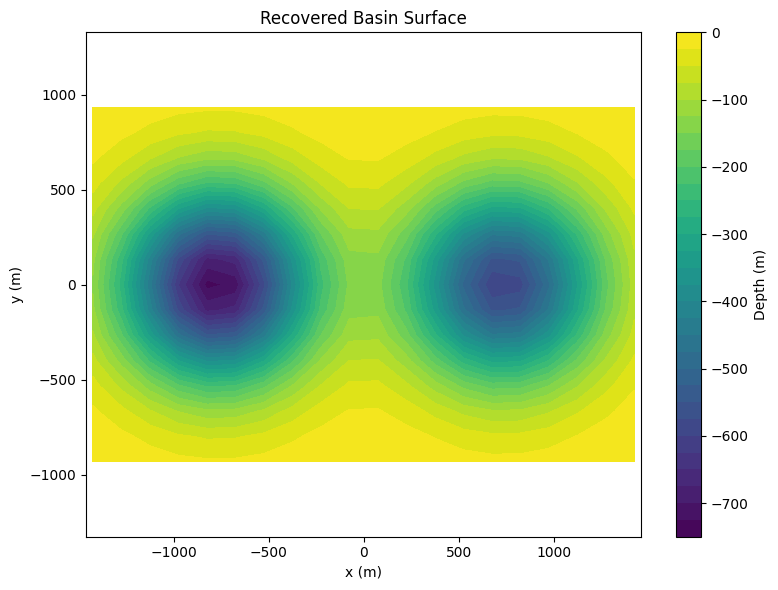


--- Recovered Basin Shape Summary ---
Max Depth: -734.11 m
Mean Depth: -169.26 m
Sigma (spread): 349.53 m


In [7]:
gz_recovered = forward_model(result.x)
# Extract recovered parameters
h1_rec, h2_rec, x1_rec, x2_rec, sigma_rec = result.x

# Compute recovered basin surface
basin_surface_rec = -(h1_rec * np.exp(-((Xc[:, :, 0] - x1_rec)**2 + Yc[:, :, 0]**2) / (2 * sigma_rec**2)) +
                      h2_rec * np.exp(-((Xc[:, :, 0] - x2_rec)**2 + Yc[:, :, 0]**2) / (2 * sigma_rec**2)))

# --- Plot recovered basin surface ---
plt.figure(figsize=(8, 6))
contour = plt.contourf(Xc[:, :, 0], Yc[:, :, 0], basin_surface_rec, levels=30, cmap='viridis')
plt.colorbar(contour, label='Depth (m)')
plt.title("Recovered Basin Surface")
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.axis('equal')
plt.tight_layout()
plt.show()

# Optional: print some stats or summary
print("\n--- Recovered Basin Shape Summary ---")
print(f"Max Depth: {np.min(basin_surface_rec):.2f} m")
print(f"Mean Depth: {np.mean(basin_surface_rec):.2f} m")
print(f"Sigma (spread): {sigma_rec:.2f} m")


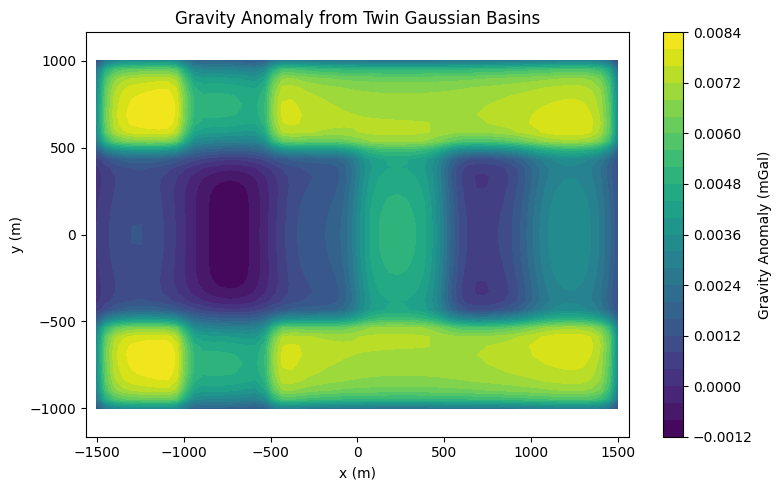

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from gravity3d import compute_gravity  # from your uploaded module

# --- Constants ---
G = 6.67430e-11         # m^3/kg/s^2
G_mGal = G * 1e5        # convert to mGal
density_contrast = 300  # kg/m^3 sediment less dense

# --- High resolution grid setup ---
Lx, Ly = 3000, 2000
nx, ny, nz = 6,4,10  # chosen resolution
x_edges = np.linspace(-Lx/2, Lx/2, nx+1)
y_edges = np.linspace(-Ly/2, Ly/2, ny+1)
z_edges = np.linspace(-600, 0, nz+1)
xc = 0.5 * (x_edges[:-1] + x_edges[1:])
yc = 0.5 * (y_edges[:-1] + y_edges[1:])
Xc, Yc = np.meshgrid(xc, yc, indexing='ij')

# --- True synthetic twin Gaussian basin ---
h1, h2 = 600, 300
x1, x2 = -800, 800
sigma = 400
true_surface = -(h1 * np.exp(-((Xc - x1)**2 + Yc**2) / (2 * sigma**2)) +
                 h2 * np.exp(-((Xc - x2)**2 + Yc**2) / (2 * sigma**2)))

# --- True density model ---
rho_true = np.zeros((nx, ny, nz))
for iz in range(nz):
    z_top = z_edges[iz + 1]
    rho_true[:, :, iz] = density_contrast * (z_top < true_surface)

# --- Observation points ---
x_obs = np.linspace(-Lx/2, Lx/2, 60)
y_obs = np.linspace(-Ly/2, Ly/2, 40)
Xobs, Yobs = np.meshgrid(x_obs, y_obs, indexing='ij')
Zobs = np.zeros_like(Xobs)

# --- Compute gravity anomaly ---
gz = compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_true)

# --- Plot gravity anomaly ---
plt.figure(figsize=(8, 5))
cp = plt.contourf(Xobs, Yobs, gz, 30, cmap='viridis')
plt.colorbar(cp, label='Gravity Anomaly (mGal)')
plt.title("Gravity Anomaly from Twin Gaussian Basins")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.axis('equal')
plt.tight_layout()
plt.show()


Text(0, 0.5, 'y (m)')

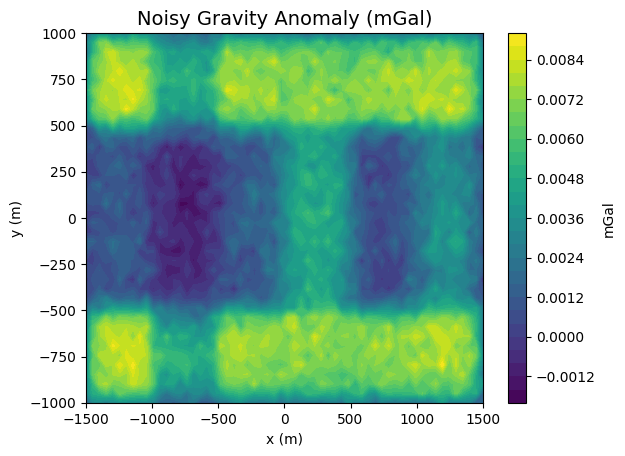

In [7]:
noise_std = 0.0005  # mGal
gz_noisy = gz + np.random.normal(0, noise_std, gz.shape)

plt.contourf(Xobs, Yobs, gz_noisy, 30, cmap='viridis')
plt.title("Noisy Gravity Anomaly (mGal)", fontsize=14)
plt.colorbar(label='mGal')
plt.xlabel("x (m)")
plt.ylabel("y (m)")



In [8]:
from scipy.optimize import differential_evolution
n_params = nx * ny  # one depth value per surface grid cell
bounds = [(-600, 0)] * n_params  # search within full depth range

# --- Helper to build a binary density model from surface ---
def build_density_model(surface_depths):
    surface = surface_depths.reshape((nx, ny))
    rho_model = np.zeros((nx, ny, nz))
    for iz in range(nz):
        z_top = z_edges[iz + 1]
        rho_model[:, :, iz] = density_contrast * (z_top < surface)
    return rho_model

# --- Cost function for inversion ---
def cost_function(surface_flat):
    surface_depths = surface_flat.reshape((nx, ny))
    rho_test = build_density_model(surface_depths)
    gz_pred = compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_test)
    return np.sqrt(np.mean((gz_pred - gz_noisy)**2))  # RMSE

# --- 3. Differential Evolution Inversion with Progress Indicator ---
iteration_counter = [0]  # Use list to make it mutable in callback

def progress_callback(xk, convergence):
    iteration_counter[0] += 1
    current_cost = cost_function(xk)
    print(f"Iteration {iteration_counter[0]:3d} | Current RMSE: {current_cost:.4f} mGal")

print("Starting inversion... This may take a while.")
result = differential_evolution(
    cost_function,
    bounds,
    strategy='best1bin',
    popsize=10,
    maxiter=50,
    polish=True,
    callback=progress_callback,
    disp=False  # turn this on if you want internal DE messages
)

recovered_surface = result.x.reshape((nx, ny))


Starting inversion... This may take a while.
Iteration   1 | Current RMSE: 0.0028 mGal
Iteration   2 | Current RMSE: 0.0025 mGal
Iteration   3 | Current RMSE: 0.0019 mGal
Iteration   4 | Current RMSE: 0.0019 mGal
Iteration   5 | Current RMSE: 0.0019 mGal
Iteration   6 | Current RMSE: 0.0018 mGal
Iteration   7 | Current RMSE: 0.0018 mGal
Iteration   8 | Current RMSE: 0.0018 mGal
Iteration   9 | Current RMSE: 0.0018 mGal
Iteration  10 | Current RMSE: 0.0018 mGal
Iteration  11 | Current RMSE: 0.0018 mGal
Iteration  12 | Current RMSE: 0.0018 mGal
Iteration  13 | Current RMSE: 0.0018 mGal
Iteration  14 | Current RMSE: 0.0018 mGal
Iteration  15 | Current RMSE: 0.0018 mGal
Iteration  16 | Current RMSE: 0.0017 mGal
Iteration  17 | Current RMSE: 0.0014 mGal
Iteration  18 | Current RMSE: 0.0013 mGal
Iteration  19 | Current RMSE: 0.0013 mGal
Iteration  20 | Current RMSE: 0.0012 mGal
Iteration  21 | Current RMSE: 0.0012 mGal
Iteration  22 | Current RMSE: 0.0012 mGal
Iteration  23 | Current RMSE: 0

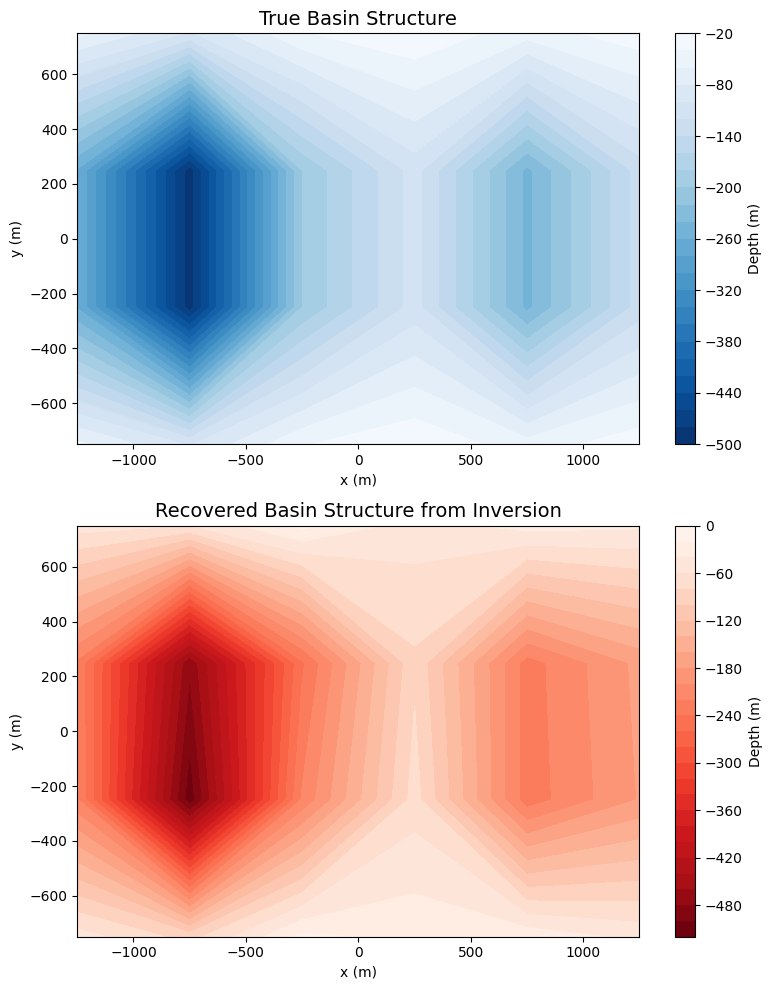

In [10]:
# Correct shapes: all must be (nx, ny)
Xc, Yc = np.meshgrid(xc, yc, indexing='ij')  # Shape: (nx, ny)

# Ensure recovered_surface shape matches
recovered_surface = result.x.reshape((nx, ny))  # Shape: (nx, ny)

# Make sure this comes *after* you’ve reshaped correctly
plt.figure(figsize=(8, 10))

# --- True Surface ---
plt.subplot(2, 1, 1)
plt.contourf(Xc, Yc, true_surface, levels=30, cmap='Blues_r')
plt.title("True Basin Structure", fontsize=14)
plt.colorbar(label='Depth (m)')
plt.xlabel("x (m)")
plt.ylabel("y (m)")

# --- Recovered Surface ---
plt.subplot(2, 1, 2)
plt.contourf(Xc, Yc, recovered_surface, levels=30, cmap='Reds_r')
plt.title("Recovered Basin Structure from Inversion", fontsize=14)
plt.colorbar(label='Depth (m)')
plt.xlabel("x (m)")
plt.ylabel("y (m)")

plt.tight_layout()
plt.show()



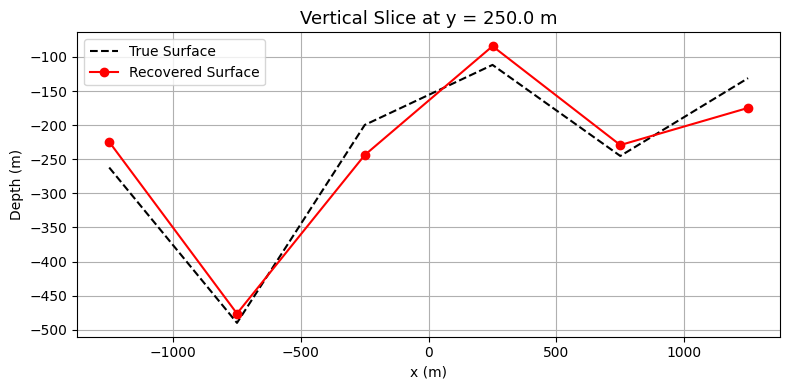

2


In [11]:
# # Index along the y-axis (middle slice)
jy = (true_surface.shape[1] // 2)

 # Extract vertical slice at y = constant (i.e., along x direction)
true_slice_yconst = true_surface[:, jy]
recovered_slice_yconst = recovered_surface[:, jy]

# Plot
plt.figure(figsize=(8, 4))
plt.plot(xc, true_slice_yconst, '--k', label='True Surface')
plt.plot(xc, recovered_slice_yconst, '-or', label='Recovered Surface')

plt.title(f"Vertical Slice at y = {yc[jy]:.1f} m", fontsize=13)
plt.xlabel("x (m)")
plt.ylabel("Depth (m)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(jy)

In [13]:
rmse_history = [
    0.0028, 0.0025, 0.0019, 0.0019, 0.0019, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018,
    0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0017, 0.0014, 0.0013, 0.0013, 0.0012,
    0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0011,
    0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0009, 0.0008, 0.0007, 0.0007, 0.0007,
    0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0006, 0.0006, 0.0006
]


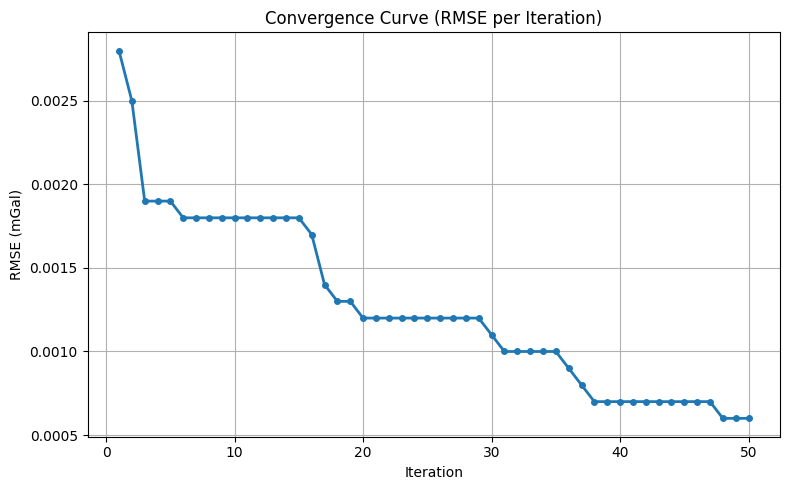

In [14]:
import matplotlib.pyplot as plt

iterations = list(range(1, len(rmse_history) + 1))  # Iteration 1 to 50

plt.figure(figsize=(8, 5))
plt.plot(iterations, rmse_history, marker='o', linewidth=2, markersize=4)
plt.xlabel('Iteration')
plt.ylabel('RMSE (mGal)')
plt.title('Convergence Curve (RMSE per Iteration)')
plt.grid(True)
plt.tight_layout()
plt.show()
